# 01 — Exploring Calgary's water main data

**Problem:** each year Calgary can replace only ~1% of its water mains (over a 5-year horizon).
Which pipes should it replace first so the most future breaks are avoided?

This notebook builds an understanding of the data before any modelling:

1. Look at the raw rows
2. Sort every column into ID / categorical / continuous / datetime / geometry
3. Continuous columns: percentiles, then distributions
4. Categorical columns: counts
5. Link each break to the pipe it happened on
6. What the prediction target looks like

**No peeking at the test period:** the final model is tested on breaks in 2021–2025, so any
target-related look in this notebook uses only breaks **before 2021**.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data import link_breaks_to_pipes, load_breaks, load_pipes

pd.set_option("display.max_columns", 30)
pipes, geoms = load_pipes()
breaks = load_breaks()
print(f"pipes: {pipes.shape}   breaks: {breaks.shape}")

pipes: (60740, 7)   breaks: (37538, 7)


# Part 1 — What do the rows look like?

### breaks — one row per recorded water main break

In [2]:
breaks[['BREAK_DATE', 'BREAK_TYPE', 'STATUS', 'point']].head()

,BREAK_DATE,BREAK_TYPE,STATUS,point
0,1978/04/01,C,ACTIVE,POINT (-114.0570152 50.9991217)
1,1982/09/01,AC,ACTIVE,POINT (-114.2013989 51.0867841)
2,1978/10/01,B,RETIRED,POINT (-114.0614874 51.0924081)
3,1978/08/01,E,ACTIVE,POINT (-114.0689266 51.0014316)
4,1990/02/01,A,RETIRED,POINT (-114.0753895 51.092555)


### pipes — one row per pipe segment in the ground today

In [3]:
pipes.head()

,year,globalid,status_ind,material,length,p_zone,diam
0,2003,493983f6-25ae-4a01-831b-6eb2d9731557,ACTIVE,PVC,2.4321,BROADCAST HILL,200
1,2001,e7994366-d91d-44eb-84a9-0f83b96ede7a,ACTIVE,PVC,49.5008,BROADCAST HILL,200
2,2003,1823b7ea-dbb8-4b08-b5f4-07fec8a0b180,ACTIVE,PVC,2.5093,BROADCAST HILL,200
3,2000,fd27ce5b-bcd1-4bc6-8f5e-af58a45da7b2,ACTIVE,PVC,11.0720,BROADCAST HILL,250
4,2003,b6712f69-25be-4916-9250-b7df862306d7,ACTIVE,PVC,148.2202,BROADCAST HILL,250


**Pattern:** two tables with **no shared ID**. A break has a date, a failure code, a status and a
location; a pipe has material, diameter (`diam`, mm), install `year`, `length` (m) and a pressure zone
(`p_zone`). The only link between them is location — handled in Part 5.

# Part 2 — What kind of column is each one?

In [4]:
def profile(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(),
        "null_%": (df.isna().mean() * 100).round(1),
        "example": df.iloc[0].astype(str).str[:30],
    })

print("=== breaks ==="); print(profile(breaks[["BREAK_DATE", "BREAK_TYPE", "STATUS", "point"]]).to_string())
print("\n=== pipes ==="); print(profile(pipes).to_string())

=== breaks ===
           dtype  n_unique  null_%                         example
BREAK_DATE   str      5865     0.0                      1978/04/01
BREAK_TYPE   str       157     0.0                               C
STATUS       str         2     0.0                          ACTIVE
point        str     37464     0.0  POINT (-114.0570152 50.9991217

=== pipes ===
              dtype  n_unique  null_%                         example
year          int64       113     0.0                            2003
globalid        str     60740     0.0  493983f6-25ae-4a01-831b-6eb2d9
status_ind      str         3     0.0                          ACTIVE
material        str        25     0.0                             PVC
length      float64     55665     0.0                          2.4321
p_zone          str        45     2.4                  BROADCAST HILL
diam          int64        33     0.0                             200


Reading the profile — storage type alone is misleading:

- `diam` is stored as a number but takes a few **standard sizes** (150, 200, 250 mm…) — closer to an
  ordered category than a free measurement.
- `year` is a number, but what matters physically is **age** at the time of prediction.
- `BREAK_TYPE` looks like free text but is a **code for how the pipe failed** (decoded in Part 4);
  combinations such as `AC` mean two failure modes at once.
- `globalid` is an identifier with no meaning to a model.

In [5]:
COLUMN_KIND = {
    "id": ["globalid"],
    "datetime": ["BREAK_DATE"],
    "categorical": ["BREAK_TYPE", "STATUS", "material", "p_zone", "status_ind"],
    "ordinal (standard sizes)": ["diam"],
    "continuous": ["length", "year"],
    "geometry": ["point", "pipe line (separate geometry list)"],
}
covered = {c for cols in COLUMN_KIND.values() for c in cols}
assert set(pipes.columns) <= covered and {"BREAK_DATE", "BREAK_TYPE", "STATUS", "point"} <= covered
pd.Series({k: ", ".join(v) for k, v in COLUMN_KIND.items()}, name="columns").to_frame()

,columns
id,globalid
datetime,BREAK_DATE
categorical,"BREAK_TYPE, STATUS, material, p_zone, status_ind"
ordinal (standard sizes),diam
continuous,"length, year"
geometry,"point, pipe line (separate geometry list)"


# Part 3 — Continuous columns

### 3.1 Percentiles first

In [6]:
PCT = [.01, .05, .25, .5, .75, .95, .99]
pipes[["length", "year", "diam"]].describe(percentiles=PCT).T.round(1)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
length,60740.0,89.2,113.7,0.0,0.7,1.7,11.8,58.8,119.9,283.1,491.6,3194.1
year,60740.0,1988.6,21.9,1900.0,1910.0,1953.0,1975.0,1992.0,2004.0,2020.0,2023.0,2033.0
diam,60740.0,246.5,158.5,0.0,50.0,150.0,150.0,200.0,300.0,400.0,1050.0,1950.0


**What stands out:**

- **Length is very skewed:** median ~59 m; 5% of segments are longer than ~280 m and 5% shorter than
  ~2 m. Short fragments exist because the GIS splits pipes at junctions.
- **Install years** run from 1900 to recent; half of the network is younger than ~1992 — the city
  roughly doubled in size in the last 40 years.
- A few install years lie in the **future** (max 2033) and a few diameters are **0** — planned or
  mis-keyed records, to be filtered before modelling.

The exact values are in the table above; the next plots show the shapes.

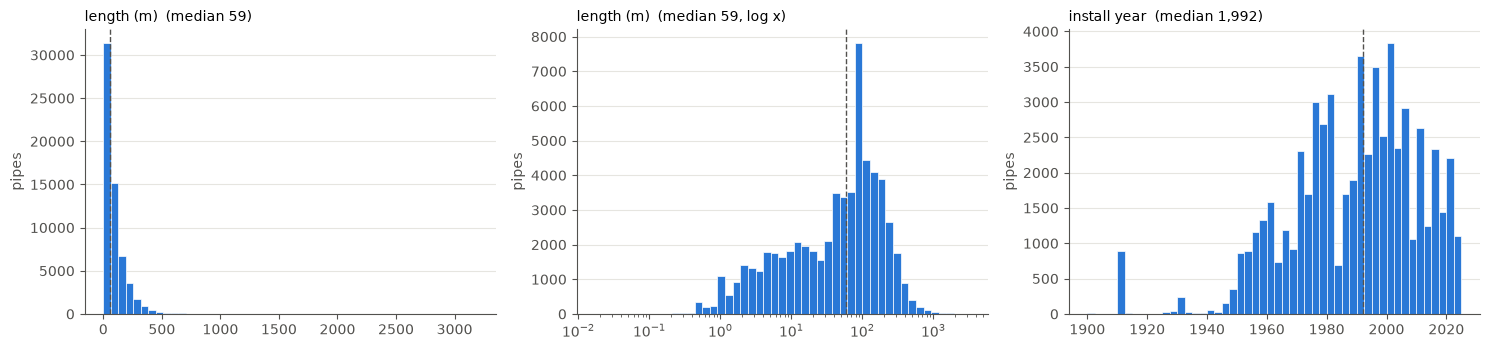

In [7]:
BLUE, ORANGE, INK = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e6e5e0", "axes.axisbelow": True,
})

def dist(ax, s, title, log=False):
    s = s.dropna()
    if log:
        s = s[s > 0]
        bins = np.logspace(np.log10(s.min()), np.log10(s.max()), 50)
        ax.set_xscale("log")
    else:
        bins = 50
    ax.hist(s, bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)
    ax.axvline(s.median(), color=INK, linestyle="--", linewidth=1)
    ax.set_title(f"{title}  (median {s.median():,.0f}{', log x' if log else ''})", fontsize=10, loc="left")
    ax.set_ylabel("pipes")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
dist(axes[0], pipes.length, "length (m)")
dist(axes[1], pipes.length, "length (m)", log=True)
dist(axes[2], pipes.year[pipes.year <= 2026], "install year")
fig.tight_layout()

**Reading the plots** (dashed line = median):

- **Length** on a normal scale is one tall bar near zero; on a log scale it becomes a hump around
  50–150 m with a tail of tiny fragments. Length must be handled carefully: a long pipe breaks more
  just because there is more of it.
- **Install year** shows building waves — the network grew in bursts, so pipe age and material are
  tied to the era a neighbourhood was built.

# Part 4 — Categorical columns

### 4.1 Pipe material — by count and by length

Total network: 5,419 km in 60,740 segments


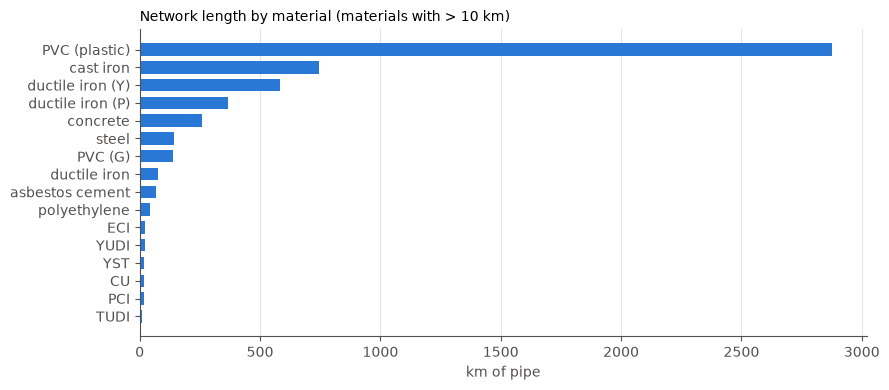

In [8]:
MATERIAL_NAMES = {"PVC": "PVC (plastic)", "CI": "cast iron", "YDI": "ductile iron (Y)", "PDI": "ductile iron (P)",
                  "CON": "concrete", "ST": "steel", "PVCG": "PVC (G)", "DI": "ductile iron", "AC": "asbestos cement",
                  "PE": "polyethylene"}
km = (pipes.groupby("material").length.sum() / 1000).sort_values()
km = km[km > 10]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh([MATERIAL_NAMES.get(m, m) for m in km.index], km.values, color=BLUE, height=0.7)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("km of pipe"); ax.set_title("Network length by material (materials with > 10 km)", fontsize=10, loc="left")
fig.tight_layout()
print(f"Total network: {pipes.length.sum() / 1000:,.0f} km in {len(pipes):,} segments")

**Finding:** about half the network is **PVC** (laid since the 1970s–80s). **Cast iron** — the
material utilities worldwide associate with breaks — is still a large share. The material names are
the data's codes; the readable labels are added for the plot.

### 4.2 How pipes fail — the break codes

Breaks with more than one failure mode: 31%


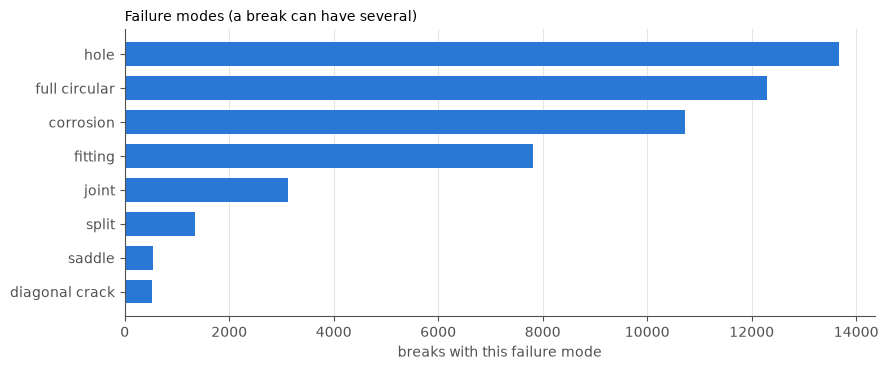

In [9]:
MODES = {"A": "full circular", "B": "split", "C": "corrosion", "D": "fitting",
         "E": "joint", "F": "diagonal crack", "G": "hole", "S": "saddle"}
letters = breaks.BREAK_TYPE.str.replace(r"\d", "", regex=True)
mode_counts = pd.Series({name: letters.str.contains(code).sum() for code, name in MODES.items()}).sort_values()
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(mode_counts.index, mode_counts.values, color=BLUE, height=0.7)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("breaks with this failure mode")
ax.set_title("Failure modes (a break can have several)", fontsize=10, loc="left")
fig.tight_layout()
print(f"Breaks with more than one failure mode: {(letters.str.len() > 1).mean():.0%}")

**Finding:** the code definitions come from the dataset's own metadata. Full circular cracks, holes and
corrosion dominate. Many breaks combine modes (e.g. a circular crack *with* corrosion). The label will
count **all** breaks: replacing a segment renews the pipe, joints and fittings, so it prevents every mode.

### 4.3 Break status, and breaks over time

STATUS
RETIRED    22255
ACTIVE     15283

Breaks dated on the 1st of a month: 79%


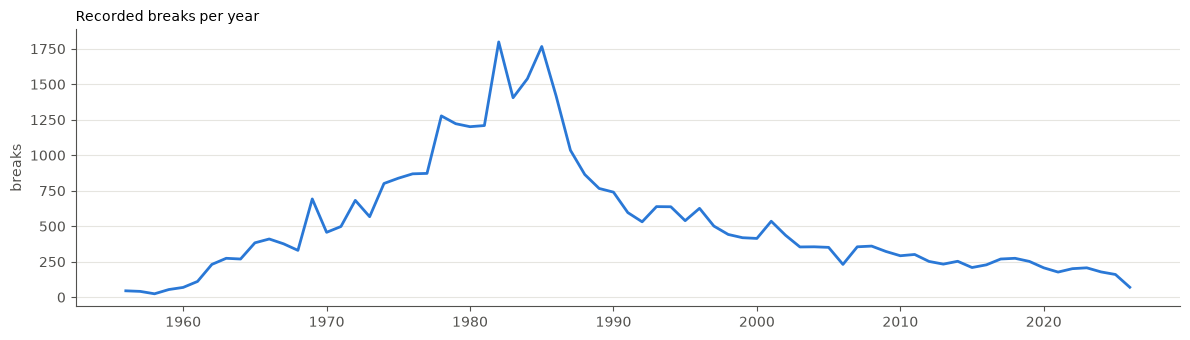

In [10]:
print(breaks.STATUS.value_counts().to_string())
per_year = breaks.groupby(breaks.break_date.dt.year).size()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(per_year.index, per_year.values, color=BLUE, linewidth=2)
ax.set_ylabel("breaks"); ax.set_title("Recorded breaks per year", fontsize=10, loc="left")
fig.tight_layout()
print(f"\nBreaks dated on the 1st of a month: {(breaks.break_date.dt.day == 1).mean():.0%}")

**Findings:**

- Breaks **peaked in the 1980s** (~1,800 in a single year) and fell steeply since, while the network kept growing —
  newer materials and decades of replacement. The rate a model learns from older years will be too
  high for today: **drift**, which matters later for calibration. (2026 is a partial year.)
- `STATUS` is ACTIVE or RETIRED; the metadata doesn't define it — Part 5 tests what it means.
- **Most breaks are dated the 1st of the month**, so dates are effectively month-precision. A 5-year
  prediction horizon makes that harmless.

# Part 5 — Linking each break to its pipe

Breaks carry no pipe ID, so each break is attached to the **nearest pipe**. Two checks decide whether
that is trustworthy: how far is the nearest pipe, and does the matched pipe make sense in time?

In [11]:
linked = link_breaks_to_pipes(breaks, geoms)
linked = linked.join(pipes[["year", "material", "length"]], on="pipe_idx")
print("Distance from break to nearest pipe (m):")
print(linked.link_dist_m.describe(percentiles=[.5, .9, .99]).round(2)[["50%", "90%", "99%", "max"]].to_string())

linked["pipe_newer_than_break"] = linked.year > linked.break_date.dt.year
linked.groupby("STATUS").pipe_newer_than_break.mean().rename("share matched to a pipe installed after the break").round(3)

Distance from break to nearest pipe (m):
50%     0.77
90%     1.10
99%     1.25
max    59.11


STATUS
ACTIVE     0.004
RETIRED    0.919
Name: share matched to a pipe installed after the break, dtype: float64

**Findings:**

- Breaks sit **about 1 m from a pipe** (99% within 1.3 m) — they were recorded on the pipe line itself,
  so the nearest-pipe match is reliable. A handful of outliers sit up to ~60 m away.
- For **RETIRED** breaks, the matched pipe was almost always installed **after** the break: the pipe
  that broke has since been **replaced**, and today's inventory only has its successor.
- For **ACTIVE** breaks that almost never happens.

So `STATUS` = whether the broken pipe is still in the ground (an inference, not documented).
**Decision:** use ACTIVE breaks only — they belong to pipes we can still describe and rank.
**Limitation (survivorship):** pipes already replaced, likely among the worst, are missing from the
inventory and from training.

In [12]:
active = linked[(linked.STATUS == "ACTIVE") & ~linked.pipe_newer_than_break].copy()
print(f"Usable breaks: {len(active):,} of {len(linked):,}, on {active.pipe_idx.nunique():,} pipes")

Usable breaks: 15,216 of 37,538, on 6,587 pipes


# Part 6 — What does the prediction target look like?

The target: **for each pipe in the ground on 1 January of a planning year, how many times will it break
in the next 5 years?** To avoid looking at the test period, this section uses the planning date
**1 Jan 2011** and breaks in **2011–2015**.

In [13]:
CUT, H = 2011, 5
cohort = pipes[(pipes.year < CUT) & (pipes.length > 0)].copy()
cohort["km"] = cohort.length / 1000
past = active[active.break_date.dt.year < CUT].groupby("pipe_idx").size()
future = active[active.break_date.dt.year.between(CUT, CUT + H - 1)].groupby("pipe_idx").size()
cohort["past_breaks"] = cohort.index.map(past).fillna(0)
cohort["target"] = cohort.index.map(future).fillna(0)

print("Breaks per pipe in 2011-2015:")
print(cohort.target.value_counts().sort_index().to_string())
print(f"\nPipes that broke at least once: {(cohort.target > 0).mean():.1%}")

Breaks per pipe in 2011-2015:
target
0.0    49836
1.0      769
2.0       96
3.0        9
4.0        2

Pipes that broke at least once: 1.7%


**Finding:** about 98% of pipes have **zero** breaks in five years. The target is a rare count — so
accuracy is useless ("never breaks" scores ~99%), and the metric must reflect the city's budget:
**recall at 1% of network length** (of all breaks, the share on the riskiest 1% of km).

### 6.1 Break rate by material and by install decade

,km,rate
material,,
CON,245.3,0.1
PVC,2245.2,0.1
PVCG,140.2,0.3
ST,115.6,1.2
YDI,583.2,3.9
AC,66.4,4.8
PDI,367.2,9.5
DI,74.4,9.9
CI,743.0,15.9


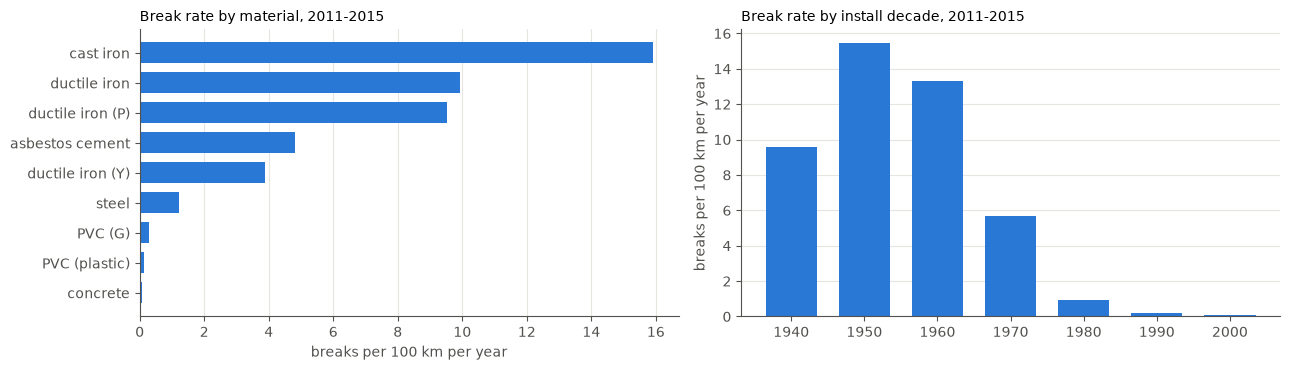

In [14]:
def rate_per_100km_yr(df):
    return df.target.sum() / (df.km.sum() * H) * 100

by_mat = cohort.groupby("material").apply(lambda d: pd.Series({"km": d.km.sum(), "rate": rate_per_100km_yr(d)}))
by_mat = by_mat[by_mat.km > 50].sort_values("rate")
cohort["decade"] = (cohort.year // 10 * 10).clip(1940, 2000)
by_dec = cohort.groupby("decade").apply(rate_per_100km_yr)

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 3.8))
a.barh([MATERIAL_NAMES.get(m, m) for m in by_mat.index], by_mat.rate, color=BLUE, height=0.7)
a.grid(axis="x"); a.grid(axis="y", visible=False)
a.set_xlabel("breaks per 100 km per year"); a.set_title("Break rate by material, 2011-2015", fontsize=10, loc="left")
b.bar(by_dec.index.astype(int).astype(str), by_dec.values, color=BLUE, width=0.7)
b.set_ylabel("breaks per 100 km per year"); b.set_title("Break rate by install decade, 2011-2015", fontsize=10, loc="left")
fig.tight_layout()
by_mat.round(1)

**Finding:** material and era separate risk sharply — cast iron and older ductile iron break at many
times the rate of PVC, and pipes laid before the 1970s break far more than recent ones. This is why a
city's default policy is "oldest / cast iron first".

### 6.2 Do pipes that broke before break again?

In [15]:
broke_before = cohort.past_breaks > 0
print(f"Pipes with a past break: {broke_before.mean():.1%} of pipes, {cohort.km[broke_before].sum():,.0f} km")
print(f"Share of 2011-2015 breaks on those pipes: {cohort.target[broke_before].sum() / cohort.target.sum():.0%}")
print(f"Rate with past break:    {rate_per_100km_yr(cohort[broke_before]):.1f} per 100 km-yr")
print(f"Rate without past break: {rate_per_100km_yr(cohort[~broke_before]):.1f} per 100 km-yr")

h = cohort[broke_before].copy()
h["length_band"] = pd.cut(h.length, [0, 20, 50, 100, 200, 1e6], labels=["<=20 m", "20-50", "50-100", "100-200", ">200 m"])
h.groupby("length_band", observed=True).apply(lambda d: pd.Series({"pipes": len(d), "breaks_per_km_5yr": d.target.sum() / d.km.sum()})).round(2)

Pipes with a past break: 11.3% of pipes, 865 km
Share of 2011-2015 breaks on those pipes: 66%
Rate with past break:    15.3 per 100 km-yr
Rate without past break: 1.7 per 100 km-yr


,pipes,breaks_per_km_5yr
length_band,,
<=20 m,269.0,1.07
20-50,577.0,0.77
50-100,1485.0,0.90
100-200,1985.0,0.89
>200 m,1403.0,0.64


**Findings:**

- Pipes that broke before (~11% of pipes, ~16% of length) carry **about two-thirds of the next breaks**
  and break ~9x more often per km — repeat offenders.
  "Past breaks per km" is therefore a strong simple rule, and the baseline any model must beat.
- Among repeat offenders, **short segments break more per km** (~1.7x the longest band here).
  Ranking must work **per km**, because the budget is spent in km.
- The rest of the network — pipes with no break yet — is where a history rule has nothing to say.

### 6.3 Do breaks on nearby pipes signal risk for a pipe with no history?

In [16]:
from shapely.geometry import Point
from shapely.strtree import STRtree

recent = active[active.break_date.dt.year.between(CUT - 10, CUT - 1)]
tree = STRtree([Point(x, y) for x, y in zip(recent.x, recent.y)])
pipe_rows, break_rows = tree.query([geoms[i].buffer(150) for i in cohort.index], predicate="intersects")
pairs = pd.DataFrame({"pipe_idx": cohort.index.values[pipe_rows], "break_pipe": recent.pipe_idx.values[break_rows]})
pairs = pairs[pairs.pipe_idx != pairs.break_pipe]
cohort["nearby_breaks"] = cohort.index.map(pairs.groupby("pipe_idx").size()).fillna(0)

clean = cohort[~broke_before].copy()
clean["nearby"] = pd.cut(clean.nearby_breaks, [-1, 0, 1, 3, 1e9], labels=["0", "1", "2-3", "4+"])
clean.groupby("nearby", observed=True).apply(lambda d: pd.Series({"km": d.km.sum(), "rate_per_100km_yr": rate_per_100km_yr(d)})).round(2)

,km,rate_per_100km_yr
nearby,,
0,2747.14,0.79
1,480.31,3.00
2-3,433.96,4.79
4+,203.55,5.11


**Finding:** among pipes that **never broke**, those with recent breaks within 150 m break ~4-6x more
often than those with none — neighbours share soil, age, installation crew and pressure. This is
information a history-only rule cannot use, and a candidate model feature.

# Summary

1. Two tables, no shared ID; breaks link to pipes by location (~1 m apart) — reliable.
2. `STATUS = RETIRED` marks breaks on pipes since replaced → use ACTIVE breaks; survivorship is a
   stated limitation.
3. Length is heavily skewed; ranking and the budget must be **per km**.
4. Breaks peaked in the 1980s and fell since → **drift**; models trained on older years will
   over-predict today unless recalibrated.
5. Target: ~98% of pipes have zero breaks in 5 years → rare counts; metric = recall at 1% of length.
6. Signals: material and era (strong), a pipe's own break history (strongest, but only ~11% of pipes
   have one), short repeat-offender segments, and breaks on nearby pipes (for pipes with no history).